<a href="https://colab.research.google.com/github/ahcamachod/clusterizacion-de-datos-segmentacion-de-clientes/blob/main/segmentos_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=red> **Clusterización de Datos: Segmentación de clientes**

---



En este notebook estaremos desarrollando un análisis completo de Ciencia de Datos con Machine Learning para la segmentación de clientes.

### ***De manera puntual, emplearemos una técnica de segmentación del comportamiento del cliente basada en datos conocida como RFM (Recencia o Actualidad, Frecuencia, y Valor Monetario).***

El dataset utilizado fue adaptado para nuestro entrenamiento, tomando como referencia un dataset de Kaggle llamado **Brazilian E-Commerce Public Dataset by Olist**.

*dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce*

### **Importando y explorando la base**

In [ ]:
# 1°) Importamos las bibliotecas necesarias ---->

import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 2°) Vamos a cargar el archivo del dataset --->

df = pd.read_csv("/content/e_commerce.csv")
df.info()

# Vamos a ver la informacion general del dataset, nos devuelve un dataframe que nos muestra las columnas, el nombre, los datos que No son nulos
# y el tipo de cada uno de estos datos, 25 columnas, y mas abajo tenemos la descripcion de cada columna.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116581 entries, 0 to 116580
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   muestra            116581 non-null  int64  
 1   id_cliente         116581 non-null  object 
 2   id_unico_cliente   116581 non-null  object 
 3   item_id            116581 non-null  int64  
 4   cp_cliente         116581 non-null  int64  
 5   ciudad_cliente     116581 non-null  object 
 6   estado_cliente     116581 non-null  object 
 7   id_pedido          116581 non-null  object 
 8   status_pedido      116581 non-null  object 
 9   horario_pedido     116581 non-null  object 
 10  pedido_aprobado    116567 non-null  object 
 11  pedido_entregador  115368 non-null  object 
 12  pedido_entregado   114066 non-null  object 
 13  fecha_estimada     116581 non-null  object 
 14  id_vendedor        116581 non-null  object 
 15  precio             116581 non-null  float64
 16  pr

* ***Columnas y Descripción***:

**muestra**: Numeración creciente de los datos.

**id_cliente**: Número de identificación del cliente que realiza la compra.

**id_unico_cliente**: Número único para cada cliente en función de su dirección IP, independiente de la compra.

**item_id**: Número de identificación del item comprado.

**cp_cliente**: Código postal del cliente.

**ciudad_cliente**: Ciudad donde se realizó el pedido.

**estado_cliente**: Estado donde se realizó el pedido.

**id_pedido**: Número de identificación de la compra.

**status_pedido**: Status del pedido (Ej. Entregado, facturado, procesando, etc).

**horario_pedido**: Fecha y hora en la cual se realizó el pedido.

**pedido_aprobado**: Fecha y hora en la cual se aprobó el pedido.  
**pedido_entregador**: Fecha y hora en la cual se hizo entrega del pedido a la empresa transportadora.  

**pedido_entregado**:Fecha y hora en la cual se hizo entrega del pedido al cliente.

**fecha_estimada**:Fecha y hora estimada de entrega.

**id_vendedor**: Número de identificación del vendedor.

**precio**: Precio del producto.

**precio_envio**: Precio del envío.

**pago_secuencial**: Compra en la cual el cliente solicita más de una forma de pago (Ej. Crédito y débito, etc).

**pago_tipo**: Método de pago (Ej. factura, débito, voucher).

**pago_cuotas**: Número de cuotas escogido por el cliente para realizar el pago.

**pago_valor**: Valor total pago.

**review**: Nota que el consumidor da a todo el proceso.

**categoria**: Categoría del item comprado.

**cp_vendedor**: Código postal del vendedor.

**ciudad_vendedor**: Ciudad del vendedor.

**estado_vendedor**: Estado del vendedor.

In [ ]:
# 3°) Vemos una muestra de nuestro dataset --->

df.sample(5)

# Nos muestra el dataframe con todas las columnas y sus respectivos datos.

,muestra,id_cliente,id_unico_cliente,item_id,cp_cliente,ciudad_cliente,estado_cliente,id_pedido,status_pedido,horario_pedido,...,precio_envio,pago_secuencial,pago_tipo,pago_cuotas,pago_valor,review,categoria,cp_vendedor,ciudad_vendedor,estado_vendedor
61251,61251,d9b79c5c0367faa77e4be9cff715e36b,f17b1ad764b21ee284cab795b9d9d990,1,4001,bogota,DC,6f4d7831b4beb4c6c46bbcbf3a84df71,entregado,2017-08-01 09:09:14,...,12.48,1,credito,1,27.38,4,electronicos,87050,florencia,CAQ
55011,55011,1ef155243064f7c445c0d8bfaec8e12d,b7f82a696d98c03d1e804050568a99f5,1,12070,bogota,DC,e7bf6c078fcd0eac3b977d498537e2b3,entregado,2017-05-05 13:48:02,...,17.31,1,factura,1,317.21,4,informatica_accesorios,87040,florencia,CAQ
47100,47100,afd73acdd42405b032d0128e5e2f271a,1dfd2a6a5da29b716d514aad237a2b09,1,52041,yopal,CAS,67bc7ff7cf5396dc164d5d3c3d251760,entregado,2017-11-24 09:10:08,...,26.10,1,credito,15,155.10,1,relojes_regalos,14840,bogota,DC
76675,76675,8aab0bdf54d373f71d3a3fcc06e37fc2,3a549cd879a78f4e306e3b3a61e81099,1,88200,manizales,CAL,5a93cebb38f427b7931b20739631c9fa,entregado,2017-07-15 19:49:02,...,18.09,1,credito,10,137.99,5,cama_mesa_baño,13405,bogota,DC
22593,22593,6e7dc8f6ec3f0a0d72fa64992ebe2fc8,5efeef1510d928c549c082d0ef4447ac,1,72904,quibdo,CHO,f5f66dabc756cc0fc7a3ef8832233715,entregado,2018-03-17 18:06:43,...,23.91,1,factura,1,213.90,4,pet_shop,13419,bogota,DC


***Definicion:***

Datos en marketing

Segmentar a los clientes ayuda a las empresas a cerrar mejores negocios, representando una ventaja competitiva frente a la competencia. El objetivo de esta estrategia es poder obtener un mayor enfoque y ser eficaces en la actuación de la empresa junto a los clientes, reuniendo la mayor cantidad de información posible sobre el público-objetivo que pretende alcanzar.

***Con base en el uso de la segmentación de clientes como herramienta de marketing digital:***

* Las insights y percepciones obtenidas por herramientas de data science ayudan a preparar mejor las acciones y a lidiar con las preferencias y los hábitos de consumo del público.
Tanto el análisis cuantitativo como el cualitativo pueden ayudar a los equipos a identificar el comportamiento de los clientes.

### **Análisis exploratorio de los datos**

Vamos a realizar nuestro analisis exploratorio pero de manera visual.

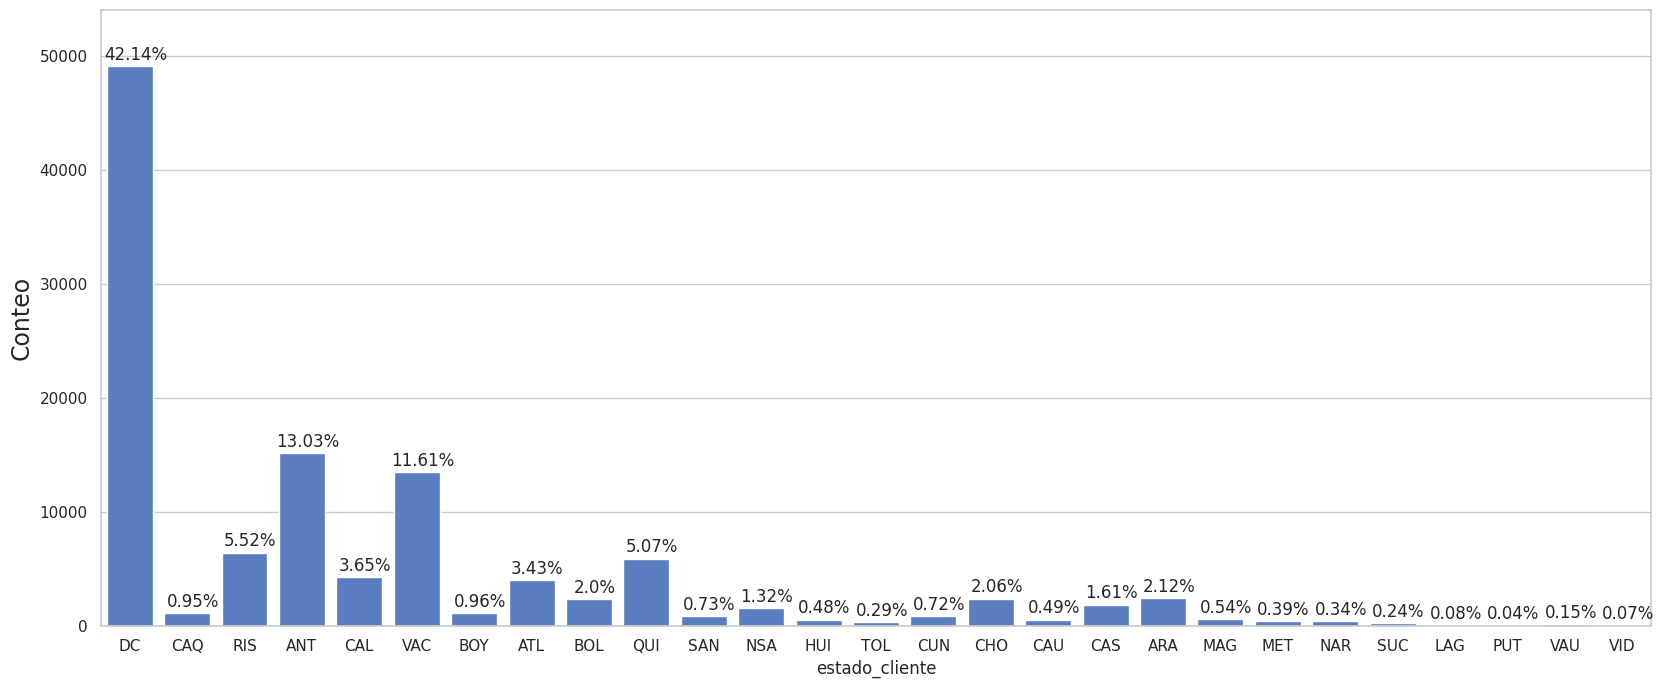

In [ ]:
# 1°) Vamos a definir una FUNCION que nos permita crear varios graficos de barras para analizar el comportamiento de los clientes y los vendedores
# en donde se encuantran cada uno(estados) ---->

def plot_porcentajes(estado, datos): # datos=df
  plt.figure(figsize=(20,8))
  grafico = sns.countplot(x=estado, data=datos, orient="h")
  grafico.set_ylabel("Conteo", fontsize=17)

# Creamos una Lista y vamos hacer una Append de las siguiente informacion:
  sizes = [] # Vamos a colocar el valor porcentual de cada una de las barras con respecto al dataset

  for p in grafico.patches:
    height = p.get_height() # Variable altura
    sizes.append(height)
    grafico.text(p.get_x() + p.get_width()/1.6,height+200,f'{round((height/len(datos)*100),2)}%',ha = 'center',va='bottom',fontsize=12)
  grafico.set_ylim(0,max(sizes)*1.1)

# Vemos el grafico de estado_cliente:
plot_porcentajes("estado_cliente", df)

# Obtenemos una grafica con nuestros ESTADOS en el eje x y el conteo de los CLIENTES que hay en cada uno de los estados en el eje y, notamos
# por ejemplo que en DC(bogota) se encuentra el 42.14 %  de clientes y el segundo estado con mas clientes vendria a ser ANT con el 13.03 %, etc.
# De esta manera vemos el porcentaje de clientes en un grafico de barras por estado.

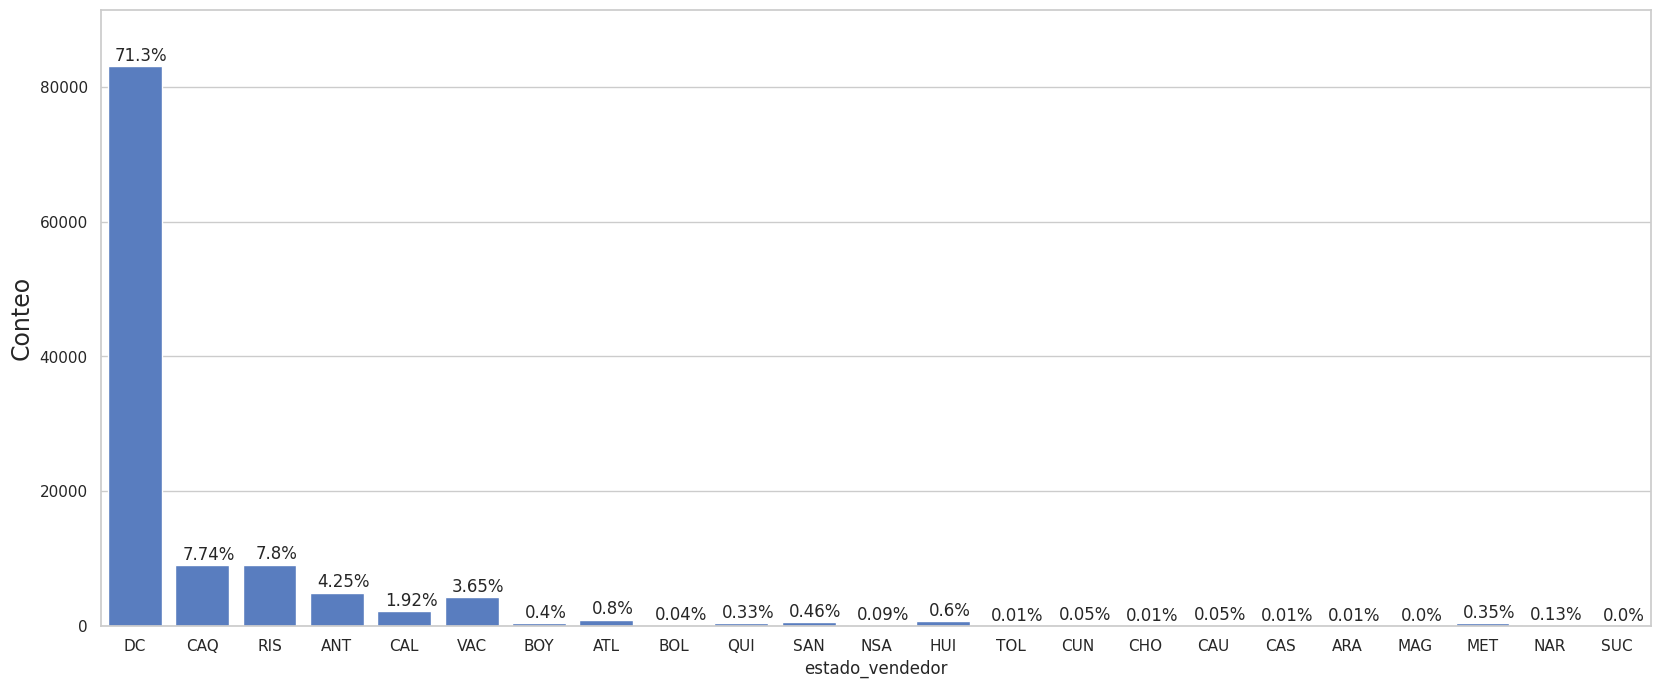

In [ ]:
# 2°) Ahora hacemos lo mismo pero para los VENDEDORES, donde se encuentran nuestros vendedores --->

# Vemos el grafico de estado_vendedor:
plot_porcentajes("estado_vendedor", df)

# Observamos que el 71.3% de los VENDEDORES se encuentran en DC(bogota) y donde hay menos vendedores por ejemplo es en MET,NAR, etc.
# Visualizando esto podemos quizas diseñar una estrategia para NO perder los clientes en los estados donde hay menos vendedores como
# en MET, NAR, como por ejemplo hacer algna promocion en el costo de envio para que NO perder las ventas en los lugares donde NO
# hay tantos vendedores

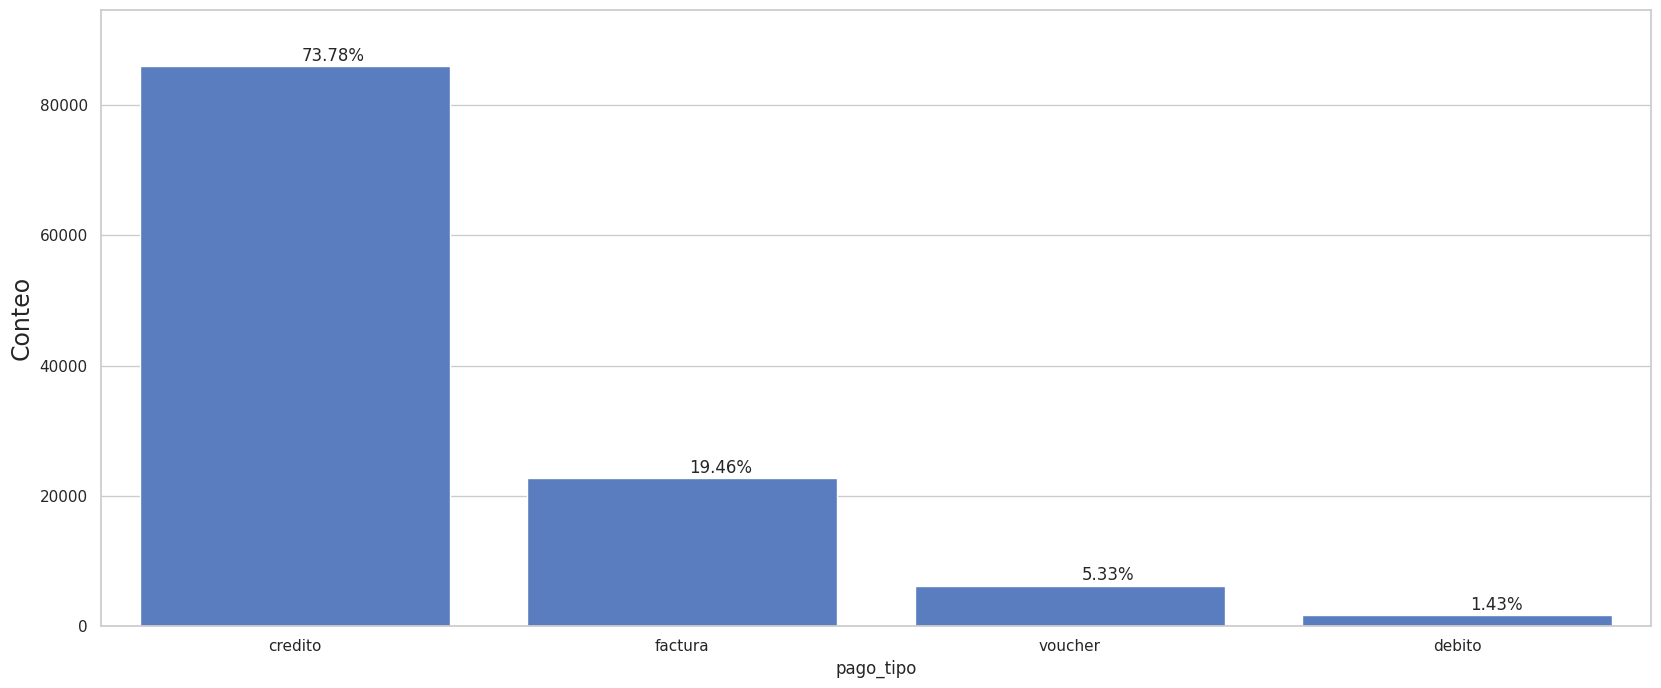

In [ ]:
# 3°) Tambien podemos hacer un PLOT del metodo de pago, como es que la gente decide pagar ---->

plot_porcentajes("pago_tipo", df)

# Nos devuelve que el 73.78 % de los clientes pagan con credito, el 1.43% con debito por jemplo, aqui se podria considerar la posibilidad de darle
# una condicion especial o descuento a los clientes que compran con debito para que se animen las personas a comprar mas utilizando este tipo de pago.

# **Analizando todas las variables**


Comenzamos a entender el problema que estamos enfrentando. La etapa de adquisición de datos es fundamental para la creación de modelos de calidad. Al considerar los atributos que tenemos en la base de datos utilizada, ***¿Qué otro tipo de problemas crees que podríamos abordar?***

* El análisis de datos puede ser realizado en todas las variables de la base de
 datos. Entretanto, existen dos problemas muy interesantes que podemos explorar:

 ***Análisis temporal:***  En esta base de datos, tenemos información de horario, fechas de compra y de entrega de nuestros clientes. Así podemos analizar:
 Si existe una temporalidad en el número de pedidos, o sea, más o menos compras en días festivos o fechas conmemorativas.
 Si existe una correlación entre los periodos de compra y de entrega y los reviews dados por los clientes o aún por el valor de envío pago.

 ***Categorías de compras:*** Podemos analizar a los clientes con base en los items que ellos normalmente compran. Al clusterizar a los clientes con base en esta información, podemos enviarles campañas de marketing orientadas al tipo de producto que ellos consumen.

# <font color=red> **Clusterización en Marketing Digital**

---

### **Modelo RFM**

Estaremos conociendo un poco más sobre el modelo RFM. Recordemos que se trata de una técnica de segmentación del comportamiento de los clientes basada en datos. RFM quiere decir recencia, frecuencia.

La palabra presencia también se puede entender como actualidad. Frecuencia y valor monetario, que sería la m que viene del inglés monetary. Entonces, para entender mejor lo que quiere decir cada una de estas siglas, cuando hablamos de recencia, entonces la pregunta que nos hacemos es: ¿hace cuánto tiempo fue la última compra que realizó este cliente?

Porque mientras más reciente haya sido esta fecha, entonces eso quiere decir que el cliente se encuentra motivado, está entusiasmado con la marca o con los productos y es muy probable que quiera volver a comprar. La frecuencia tiene que ver con cuántas compras ha hecho este cliente en tu empresa, en tu e-commerce desde que él se registró.

Entonces es importante conocer este indicador porque allí podemos saber si esta persona ya está fidelizada o no con la marca, entonces la frecuencia es muy importante y el valor monetario, lógicamente, mientras más gaste un cliente, más valor representa para la organización y a estos clientes hay que cuidarlos muy bien.

Entonces vamos a ir analizando aquí nuestro DataFrame y vamos a seleccionar de los 25 atributos que tiene los que estaremos empleando para desarrollar nuestro proyecto, que no son todos ellos. Entonces vamos a venir aquí a una de las celdas de código y vamos a crear un nuevo DataFrame que se va a llamar olist como el nombre de la e-commerce, y vamos a seleccionar del DataFrame, apenas las columnas que vamos a utilizar.

#### **Recencia (R)**
##### ¿Hace cuántos días fue la última compra que realizó este cliente?

#### **Frecuencia (F)**
##### ¿Cuántas compras este cliente hizo en tu empresa, desde que se registró?

#### **Valor Monetario (M)**
##### ¿Cuánto dinero este cliente ya gastó en tu empresa?

In [ ]:
# 1°) Vamos a crear un nuevo dataframe y vamos a seleccionar del dataframe las columnas que vamos a utilizar --->

df_olist = df[["id_unico_cliente", "id_cliente", "horario_pedido", "item_id", "precio"]]
df_olist.head()

# Nos devuelve el nuevo dataframe con las 5 columnas que queremos.

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99


In [ ]:
# 2°) Necesitamos crear un nuevo dataframe que va a ser el de la compra y en ese dataframe de compra nosotros queremos tomar y almacenar
# la fecha maxima de la compra para poder obtener posteriormente la info de RECENCIA --->

# Vamos a tomar el dataframe que creamos y agrupar por id_unico_cliente y tomamos como referencia el ultimo
# horario de cuando se realizo el pedido:
df_compra = df.groupby("id_unico_cliente").horario_pedido.max().reset_index()
# Definimos las columnas del dataset compras:
df_compra.columns = ["id_unico_cliente", "fecha_max_compra"]
# Fecha tipo DateTime de la fecha maxima de compra:
df_compra["fecha_max_compra"] = pd.to_datetime(df_compra["fecha_max_compra"])

df_compra.head()
# Nos devuelve el DataFrame con el ID unico del cliente y la fecha maxima de compra.

,id_unico_cliente,fecha_max_compra
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42


In [ ]:
# 3°) Con esta informacion podemos crear la columna RECENCIA y creamos un nuevo atributo llamado RECENCIA --->

df_compra["recencia"] = (df_compra["fecha_max_compra"].max() - df_compra["fecha_max_compra"]).dt.days # Metodo dt de datetima y tomamos los dias.
df_compra.head()

# Nos devuelve con las columnas ID_UNICO_CLIENTE, FECHA_MAX_COMPRA, RECENCIA.

,id_unico_cliente,fecha_max_compra,recencia
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,115
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,118
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,541
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,325
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,292


In [ ]:
# 4°) Creamos un nuevo dataframe para ver cada uno de los usuarios, necesitamos tomar nuestro DATAFRAME ORIGINAL y lo unimos con el
# dataframe de df_compra --->

df_usuario = pd.merge(df_olist, df_compra[["id_unico_cliente", "recencia"]], on = "id_unico_cliente")
df_usuario.head()

# Tenemos el dataframe OLIST(original) con el ID_UNICO_CLIENTE, HORARIO DE PEDIDO, PRECIO y le añadimos la RECENCIA, podemos ver por ejemplo tenemos
# un cliente que compro 1 item a tal precio determinado hace 115 dias.

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,recencia
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99,298
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99,298
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99,211


***Importancia del análisis exploratorio***

Cuando tenemos una base de datos con mucha información, es importante analizar qué es relevante. Además, debemos ser cuidadosos al añadir muchas variables para no aumentar innecesariamente la complejidad de nuestros modelos. Por este motivo, se hace necesaria la utilización del análisis exploratorio, con el propósito de obtener insights.

El gerente te solicitó que presentaras algunos gráficos diferentes. Con relación a los requerimientos de él:

* Para dejar las barras del gráfico de conteo porcentual de vendedores en un formato vertical, como solicitado por el gerente, necesitamos modificar la función countplot(), adicionando el parámetro orient='v'.
Este parámetro está directamente asociado a la posición de las barras en formato horizontal o vertical.

* Podemos alterar la altura de los textos porcentuales, escribiendo un poco más arriba de las barras modificando el comando height+200 y dejándolo height+400.
El número después de la variable “height” muestra la cantidad de pixeles adicionales que deben ser colocados en la posición del texto.



### **Regla del CODO**

Ahora, necesitamos usar el Método del Codo, la idea es ejecutar el algoritmo KMeans para varias cantidades diferentes de clusters y así poder determinar el número ideal de clusters.

A medida que aumentamos el número de clusters con KMeans, las diferencias entre los diversos clusters disminuyen y las diferencias por dentro de los clusters van aumentando. Entonces, debemos hallar un equilibrio de modo que las observaciones que conforman cada agrupación sean lo más homogéneas posible y que las diversas agrupaciones se puedan diferenciar entre sí.



> Explicacion Teorica Cuadernillo



### **Codificando la REGLA del CODO**

Cual es el mejor numero de CLUSTERS para nuestra SEGMENTACION, codificando con la regla del CODO.

In [ ]:
# 1°) Definimos una funcion que nos permita calcularel valor de INERCIA dependiendo del numero de CLUSTERS que consideremos
# en nuestro modelaje --->

from sklearn.cluster import KMeans # Importamos KMEANS y CLUSTERS

def calcular_inercia(datos):
  inercia = [] # Lista vacia para almacenar todas los valores de inercia.
  for k in range(1,10): # K=Clusters
    kmeans = KMeans(n_clusters = k) # Instanciamos kmeans
    kmeans.fit(datos) # Fit de los datos
    datos["clusters"] = kmeans.labels_ # Creamos columna clusters en un nuevo dataframe y almacenamos en esa columna todos los labels_ que nos da kmeans = labels=atributo que ya viene con kmeans.
    inercia.append(kmeans.inertia_) # almacenamos valores en la lista vacia de con el atributo inertia_
  return inercia


In [ ]:
# 2°) Vamos a crear una variable suma cuadrados en la cual vamos a calcular la Inercia del dataframe df_usuario, pero antes vamos a crear
# una columna que se va a llamar recencia en un nuevo dataframe que solo tendra los valores de recencia de cada uno de los clientes --->

df_recencia = df_usuario[["recencia"]]
df_recencia.head()

# Nos devuelve el dataframe solo con la recencia de cuanto tiempo el cliente compro

,recencia
0,474
1,298
2,298
3,483
4,211


In [ ]:
# 3°) Calculamos ahora si la funcion de INERCIA para nuestro dataframe Recencia ---->

suma_cuadrados = calcular_inercia(df_recencia)


<ipython-input-126-9d2966ebc477>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos["clusters"] = kmeans.labels_ # Creamos columna clusters en un nuevo dataframe y almacenamos en esa columna todos los labels_ que nos da kmeans = labels=atributo que ya viene con kmeans.
<ipython-input-126-9d2966ebc477>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos["clusters"] = kmeans.labels_ # Creamos columna clusters en un nuevo dataframe y almacenamos en esa columna todos los labels_ que nos da kmeans = lab

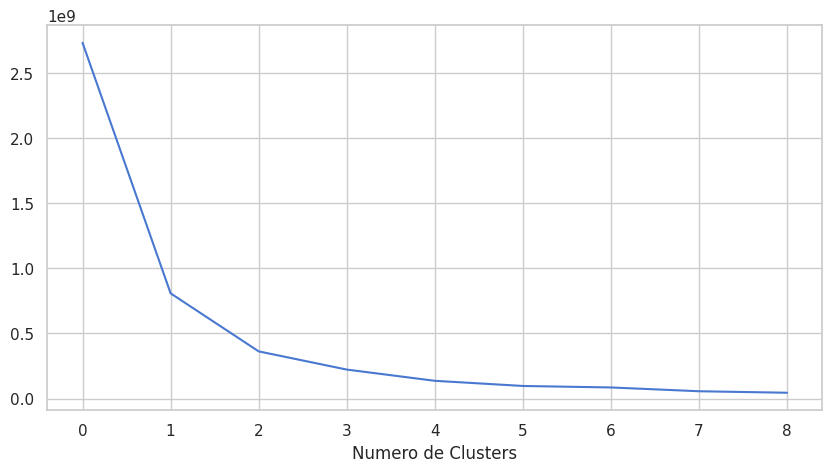

In [ ]:
# 4°) Vamos a PLOTAR el comportamiento de la INERCIA conforme el numero de CLUSTERS van aumentando --->

plt.figure(figsize=(10,5))
plt.plot(suma_cuadrados)
plt.xlabel("Numero de Clusters")
plt.show()

# Nos devuelve la grafica con el CODO, con 0 Clusters el calor de la Inercia es muy arriba, en 4 parace indicar que se estabiliza.
# Visualualmente podemos decir que 3, 4 es una buena opcion, pero para determinarlo usaremos una Regla Matematica.

***Definicion:***

Calculando la inercia

Para establecer el mejor número de clusters debemos de calcular la inercia en función del número de clusters. El objetivo de este cálculo es:

* **Disminuir la inercia dejando un número razonable de clusters. Este es el objetivo a la hora de establecer el número ideal de clusters.**

### **REGLA MATEMATICA**

---



***¿Cómo podemos identificar si el mejor número de clusters es 3, 4 o 5***?

***¡Existe una solución matemática!***



> ![](https://miro.medium.com/max/2775/1*9J7Wnh5L0eIcHXBeWlzvNA.png)


Lo primero que debemos hacer, es definir una recta conectando el primer punto (cluster 1) al último punto (cluster 9).

En este caso, P0 es el punto del cluster 1 y P1 es el punto del cluster 9. El par (x,y) representa las coordenadas de cualquier punto desde el cual deseemos  calcular la distancia hasta la recta. Calculando todas las distancias, lograremos determinar el punto que indica el número ideal de clusters.

### **Codificando Regla MATEMATICA**

> ![](https://miro.medium.com/max/2775/1*9J7Wnh5L0eIcHXBeWlzvNA.png)

In [ ]:
# 1°) Definimos una Funcion  --->

def numero_ideal_clusters(inercia): # Inercia = lista de valores
#Definimos las valores de x e y:
  x1,y1 = 2, inercia[0]
  x2,y2 = 20, inercia[-1] # -1 = ultimo valor de inercia en 20
  distancia = [] # Creamos una lista vacia, distancia del punto mayor de la inercia a la recta.
  for i in range(len(inercia)):
    x0 = i + 2 # Inciamos en 2 para que tome el segundo valor de Inercia
    y0 = inercia[i] # Vslor de Inercia en cada uno de los Indices
    numerador = abs((y2-y1)*x0 - (x2-x1)* y0 + x2+y1 - y2*x1) # Valores de la segunda parte de la ecuacion
    denominador = ((y2-y1)**2 + (x2-x1)*2)**(1/2) # Division de la segunda parte de la ecuacion, 1/2= Raiz cuadrada es lo mismo que elevado a la 1/2
    distancia.append(numerador/denominador)

  return distancia



In [ ]:
# 2°) Hacemos un PRINT --->

print(f"El numero ideal de Clusters es: {numero_ideal_clusters(suma_cuadrados)}") # suma al cuadrado, donde almacenamos los valores de Inercia.

# Nos devuleve la lista de distancia pero nosotros queremos el valor maximo de distancia, agragamos a la funcion el valor maximo.

El numero ideal de Clusters es: [19.312489775876998, 7.424899393714541, 5.440181994650683, 5.504251830927472, 5.926645569022343, 6.661415660013014, 7.584632675443609, 8.389870315842655, 9.312489775877001]


In [ ]:
# 3°) Agregamos a la funcion el maximo de la distancia --->

def numero_ideal_clusters(inercia):
  x1,y1 = 2, inercia[0]
  x2,y2 = 20, inercia[-1]

  distancia = []

  for i in range(len(inercia)):
    x0 = i+2
    y0 = inercia[i]
    numerador = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1)
    denominador = ((y2-y1)**2 + (x2-x1)**2)**(1/2)
    distancia.append(numerador/denominador)

  return distancia.index(max(distancia)) + 2 # Valor maximo de distancia y que arranque de 2

print(f"El numero ideal de Clusters es: {numero_ideal_clusters(suma_cuadrados)}")

# Nos devuelve que el numero ideal de CLUSTERS es 4!

El numero ideal de Clusters es: 4


# <font color=red> **Clusterización del Modelo RFM**

---

### **Clusterizando a RECENCIA**

In [ ]:
# 1°) Primero vamos a INSTANCIAR KMeans --->

kmeans = KMeans(n_clusters=4) # Instanciamos kmeans con el numero 4 clusters, que fue lo que nos arrojo como optimo regla Matematica.
df_usuario["recencia_cluster"] = kmeans.fit_predict(df_recencia) # Almacenamos en el df usuario un columna con el fit de del df recencia y los 4 clusters.
df_usuario.head()

# NOs devuelbe el dataframe con el cluster que el algoritmo asigno a cada unos de los usuarios.

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,recencia,recencia_cluster
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,1
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99,298,3
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99,298,3
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,1
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99,211,0


In [ ]:
# 2°) Ahora lo que debemos hacer es realizar una agrupacion por CLUSTERS, para esto creamos una nueva variable --->

agrupado_por_cluster = df_usuario.groupby("recencia_cluster")["recencia"].mean().reset_index()
agrupado_por_cluster.head()

# Nos devuelve la agrupacion de Clusters, podemos ver que a la compra mas reciente del cliente lo coloco en el cluster 0, el que compro hace mas tiempo
# lo coloco en el cluster 2, y nosotros NO queremos eso!, queremos que los que compraron mas recientemente esten en un CLUSTER que tengan el valor
# mayor, debemos ordenar.

,recencia_cluster,recencia
0,0,187.076277
1,1,489.070832
2,2,66.405850
3,3,318.687376


In [ ]:
# 3°) Vamos a ordenar  nuestros Clusters --->

agrupado_por_cluster_ordenado = agrupado_por_cluster.sort_values(by="recencia", ascending=False).reset_index(drop=True)
agrupado_por_cluster_ordenado.head()

# Nos devuelve valores de compra de hace mas tiempo primero(recencia) con sus respectivos numeros de Cluster.

,recencia_cluster,recencia
0,1,489.070832
1,3,318.687376
2,0,187.076277
3,2,66.405850


In [ ]:
# 4°) Ahora debemos tomar el INDICE y ordenarlo tambien, creamos una nueva columna ---->

agrupado_por_cluster_ordenado["index"] = agrupado_por_cluster_ordenado.index
agrupado_por_cluster_ordenado.head()

# Ya nos aparece la nueva columna con el INDICE.

,recencia_cluster,recencia,index
0,1,489.070832,0
1,3,318.687376,1
2,0,187.076277,2
3,2,66.405850,3


In [ ]:
# 5°) Ahora queremos que el valor del INDICE este en RECENCIA_CLUSTER, pero antes debemos juntar nuestros clusters ---->

juntando_cluster = pd.merge(df_usuario, agrupado_por_cluster_ordenado[['recencia_cluster','index']],on= 'recencia_cluster')
juntando_cluster.head()

# Ya nos devuelve los dataframe juntos y los usuarios por recencia y con la columna INDEX

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,recencia,recencia_cluster,index
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,1,0
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99,298,3,1
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99,298,3,1
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,1,0
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99,211,0,2


In [ ]:
# 6°) Ahora creamos una nueva variable para remover lo que NO queremos --->

removiendo_datos = juntando_cluster.drop(["recencia_cluster"], axis=1) # recencia_cluster NO lo queremos mas porque fueron los cluster que nuestro computador
# asigno como el quiso que no tiene nada que ver con el orden que queremos nossotros.
removiendo_datos.head()

# No tenemos recencia_cluster, tenemos la columna INDEX que es la que queremos convertir en nuestro Recencia cluster.

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,recencia,index
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99,298,1
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99,298,1
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99,211,2


In [ ]:
# 7°) Creamos variable DF_FINAL --->

df_final = removiendo_datos.rename(columns={"index":"recencia_cluster"}) # Renombramos la columna de nuestro INDEX por RECENCIA_CLUSTER
df_final.head()

# La columna RECENCIA CLUSTER nos muestra que 0 tiene una recencia por encima de los 400 dias de la ultima compra

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,recencia,recencia_cluster
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99,298,1
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99,298,1
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99,211,2


In [ ]:
# 8°) Vamos a ver esa columna mas detallada --->

df_final.sample(3) # vemos 3 muestras aleatoreas.

# Podemos ver que el que compro hace 16 dias es parte del cluster 3, el que compro hace 293 dias e sparte del cluster 1 y el que compro hace
# 465 dias es parte del cluster o.

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,recencia,recencia_cluster
2203,93f9ccf10237ab42fd9dc37103eb7a76,e4875b1e01c4981c486839558bf6bced,2018-08-15 08:58:42,1,26.90,19,3
36302,27e92b85aef233fd7505b89acab00e90,3a825d2c5267ea3fe4af517fe5e2876b,2017-06-12 22:18:49,1,29.50,447,0
50649,ba16ab3721ffd6b57fc87a7a4f6a4fcf,5043e611d34f6ad724ca658aa22cc43c,2018-02-15 13:09:28,1,12.25,199,2


In [ ]:
# 9°) Todo esto lo tenemos que hacer tambien oara la FRECUENCIA y el VALOR MONETARIO y lo recomendado es hacer una funcion ---->

def ordenandor_cluster(cluster_actual, target, df): # Sustituimos estos parametros a las lineas de codigo ya creadas.
# Agregamos las lienas de codigo ya creadas a la funcion:
  agrupado_por_cluster = df_usuario.groupby(cluster_actual)[target].mean().reset_index()
  agrupado_por_cluster_ordenado = agrupado_por_cluster.sort_values(by=target, ascending=False).reset_index(drop=True)
  agrupado_por_cluster_ordenado["index"] = agrupado_por_cluster_ordenado.index
  juntando_cluster = pd.merge(df_usuario, agrupado_por_cluster_ordenado[[cluster_actual,'index']],on= cluster_actual)
  removiendo_datos = juntando_cluster.drop([cluster_actual], axis=1)
  df_final = removiendo_datos.rename(columns={"index":cluster_actual})
  return df_final

In [ ]:
# 10°) Vamos a utilizar la funcion --->

df_usuario = ordenandor_cluster("recencia_cluster", "recencia", df_usuario) # reemplazamos clase_actual, target y df por lo que queremos usar.
df_usuario.groupby("recencia_cluster")["recencia"].describe() # Agrupamos por recencia_cluster con respecto a la recencia.

# Nos devuleve el Describe y consideramos el valor de la MEDIA(mean) para analizar, para los clientes cuya media es de 490 dias de la ultima compra
# pertenecen al cluster 0, 320 dias de la ultima compra al cluster 1, 187 dias al cluster 2 y 66 dias la cluster 3.
# Efectivamente la Funcion trabajo como deceamos.

,count,mean,std,min,25%,50%,75%,max
recencia_cluster,,,,,,,,
0,20697.0,489.070832,59.862148,404.0,441.0,480.0,532.0,728.0
1,30695.0,318.687376,43.450070,253.0,281.0,312.0,355.0,403.0
2,33601.0,187.076277,35.024122,127.0,157.0,187.0,217.0,252.0
3,31588.0,66.405850,35.800016,0.0,33.0,67.0,99.0,126.0


**Definicion:**

***El modelo RFM***

Al analizar el modelo RFM, percibimos que los clusters deben ser ordenados de acuerdo con la puntuación que van a ganar. Suponiendo que tu gestor haya resuelto añadir una nueva variable al modelo RFM, denominada “conversion”, esta variable está relacionada al número de veces que el cliente realizó una compra por el número de veces que él accedió a la página web durante los tres últimos meses.

Para añadir esta variable en tu modelo, algunos cambios deberán ser realizados:

* En la función ordenador_cluster(), debemos modificar la función sort_values(), añadiendo el comando ascending=True.
Como queremos que el mayor valor de la variable “conversión” tenga la mayor puntuación, la organización debe ser realizada de forma ascendente.

* El modelo de puntuación deberá ser modificado.
La nueva puntuación deberá ser compuesta por: *df_final['puntuacion'] = df_usuario['recencia_cluster'] + df_usuario['frecuencia_cluster'] + df_usuario['ingresos_cluster'] + df_usuario['conversion_cluster']* y podrá sumar más de 7 puntos.

### **Clusterizando de FRECUENCIA**

In [ ]:
# 1°) Vamos a crear un nuevo dataframe que llamaremos FRECUENCIA y en el vamos a tomar el dataframe original completo y vamos a agrupar
# por el id_unico_cliente, tomaremos como referencia pedido_aprobado que son las ordenes de compra realizadas y haremos un conteo --->

df_frecuencia = df.groupby("id_unico_cliente").pedido_aprobado.count().reset_index()
df_frecuencia.columns =["id_unico_cliente", "frecuencia"] # Nombramos las columnas de nuestro dataframe
df_frecuencia.head()

# Nos devuelve el dataframe con las 2 columnas.

,id_unico_cliente,frecuencia
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [ ]:
# 2°) Ahora vamos a hacer un MERGE con el dataframe FRECUENCIA y el dataframe de USUARIO --->

df_usuario = pd.merge(df_usuario, df_frecuencia, on="id_unico_cliente") # Tomamos los 2 dataframe y los juntamos a traves(on) de id_unico_cliente.
df_usuario.head()

# Ya tenemos el dataframe de FRECUENCIA junto a de USUARIO unido a traves de la columna id_unico_cliente

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,recencia,recencia_cluster,frecuencia
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0,1
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99,298,1,2
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99,298,1,2
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0,1
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99,211,2,1


In [ ]:
# 3°) Vamos a crear un dataframe de FRECUENCIA y en el vamos a dejar unicamante la columna referente a la FRECUENCIA y luego INSTANCIAMOS
# nuestro KMEANS --->

df_frecuencia = df_usuario[["frecuencia"]]  # Use the correct column name with the leading space
kmeans = KMeans(n_clusters=4) # Instanciamos KMEANS con 4 CLUSTERS
df_usuario["frecuencia_cluster"] = kmeans.fit_predict(df_frecuencia) # Al dataframe de usuario a la columna de FRECUENCIA CLUSTER le asignamos el fit de nuestro Kmeans
df_usuario.head()

# Podemos ver la nueva columna FRECUENCIA_CLUSTER

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,recencia,recencia_cluster,frecuencia,frecuencia_cluster
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0,1,1
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99,298,1,2,1
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99,298,1,2,1
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0,1,1
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99,211,2,1,1


In [ ]:
# 4°) Vamos a ver si estos CLUSTERS corresponden con la FRECUENCIA, a menor frecuencia la persona esta en un cluster de un nuemro mas pequeño
# a moyor frecuencia mayor numero de cluster --->

df_usuario.groupby('frecuencia_cluster')["frecuencia"].describe() # Use the correct column name " frecuencia" with the leading space

# Vemos que la MEDIA con los nuemros de CLUSTER estan desordenados.



,count,mean,std,min,25%,50%,75%,max
frecuencia_cluster,,,,,,,,
0,9205.0,5.644432,2.138491,4.0,4.0,5.0,6.0,13.0
1,106570.0,1.306343,0.570539,0.0,1.0,1.0,2.0,3.0
2,75.0,75.000000,0.000000,75.0,75.0,75.0,75.0,75.0
3,731.0,21.489740,6.588977,14.0,15.0,21.0,24.0,38.0


In [ ]:
# 5°) Vamos a aplicar nuestra funcion --->

df_usuario = ordenandor_cluster('frecuencia_cluster',"frecuencia",df_usuario)

# Verificamos:
df_usuario.groupby("frecuencia_cluster")["frecuencia"].describe()

# Podemos ver que quedo al reves, con Cluster menores y Media de compras de clientes mayores, 0=75, 3=1.39

,count,mean,std,min,25%,50%,75%,max
frecuencia_cluster,,,,,,,,
0,75.0,75.000000,0.000000,75.0,75.0,75.0,75.0,75.0
1,731.0,21.489740,6.588977,14.0,15.0,21.0,24.0,38.0
2,9205.0,5.644432,2.138491,4.0,4.0,5.0,6.0,13.0
3,106570.0,1.306343,0.570539,0.0,1.0,1.0,2.0,3.0


In [ ]:
# 6°) Tenemos que modificar la funcion en orden DESCENDENTE --->

def ordenandor_cluster(cluster_actual, target, df, asc=False): # Agregamos asc=False y luego la cambiamos en el codigo mas abajo
# Agregamos las lienas de codigo ya creadas a la funcion:
  agrupado_por_cluster = df_usuario.groupby(cluster_actual)[target].mean().reset_index()
  agrupado_por_cluster_ordenado = agrupado_por_cluster.sort_values(by=target, ascending=asc).reset_index(drop=True) # Cambiamos asc
  agrupado_por_cluster_ordenado["index"] = agrupado_por_cluster_ordenado.index
  juntando_cluster = pd.merge(df_usuario, agrupado_por_cluster_ordenado[[cluster_actual,'index']],on= cluster_actual)
  removiendo_datos = juntando_cluster.drop([cluster_actual], axis=1)
  df_final = removiendo_datos.rename(columns={"index":cluster_actual})
  return df_final

# Luego lo cambiamos en el codigo de aplicar la funcion:
df_usuario = ordenandor_cluster('frecuencia_cluster',"frecuencia",df_usuario, asc=True)
# Verificamos:
df_usuario.groupby("frecuencia_cluster")["frecuencia"].describe()

# Nos devuelve como queriamos el que compra con menos Frecuencia MEDIA= 1.39 quedo en el CLUSTER=0, MEDIA= 75 quedo en el CLUSTER=3


,count,mean,std,min,25%,50%,75%,max
frecuencia_cluster,,,,,,,,
0,106570.0,1.306343,0.570539,0.0,1.0,1.0,2.0,3.0
1,9205.0,5.644432,2.138491,4.0,4.0,5.0,6.0,13.0
2,731.0,21.489740,6.588977,14.0,15.0,21.0,24.0,38.0
3,75.0,75.000000,0.000000,75.0,75.0,75.0,75.0,75.0


### **Clusterizando el VALOR MONETARIO** (Ingresos)

In [ ]:
# 1°) Vamos a crear un nuevo dataframe que llamaremos INGRESOS --->

df_ingresos = df.groupby("id_unico_cliente").pago_valor.sum().reset_index() # Agrupamos por el df original, a traves de id unico y el pago sumado de los clientes.
df_ingresos.columns = ["id_unico_cliente", "ingresos"] # Nombramos las columnas y definimos la columna de ingresos.
# Hacemos MERGE:
df_usuario = pd.merge(df_usuario, df_ingresos, on="id_unico_cliente")
df_usuario.head()

# Nos devuelve el datadframe usuario con la nueva columna ingresos.

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,recencia,recencia_cluster,frecuencia,frecuencia_cluster,ingresos
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0,1,0,146.87
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99,298,1,2,0,551.58
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99,298,1,2,0,551.58
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0,1,0,140.61
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99,211,2,1,0,137.58


In [ ]:
# 2°) Creamos nuevo dataframe que se va a llamar PAGO --->

df_pago = df_usuario[["ingresos"]]
df_pago.head()

# Nos devuelve los ingresos y estos ingresos los vamos a ingresar a nuestro Algoritmo KMEANS.

,ingresos
0,146.87
1,551.58
2,551.58
3,140.61
4,137.58


In [ ]:
# 3°) Usamos el algoritmo --->

kmeans = KMeans(n_clusters=4)
df_usuario["ingresos_cluster"] = kmeans.fit_predict(df_pago)


In [ ]:
# 4°) Aplicamos la funcion para ordenar clusters --->

df_usuario = ordenandor_cluster("ingresos_cluster", "ingresos", df_usuario, asc=True)#ingresos_cluster=cluster actual, ingresos=target

In [ ]:
# 5°) Hacemos un groupby para visualizarlo --->

df_usuario.groupby("ingresos_cluster")["ingresos"].describe()

# Nos devuelve la MEDIA, en cluster 0 lo que gastaron menos y en el cluster 3 los que gastaron mas.

,count,mean,std,min,25%,50%,75%,max
ingresos_cluster,,,,,,,,
0,115580.0,281.762163,460.784612,9.59,70.14,133.64,275.730,4513.32
1,884.0,8748.496787,4172.077041,4534.56,5649.25,7362.09,11049.495,19457.04
2,109.0,33880.448716,8751.759866,22346.60,27935.46,30186.00,44048.000,45256.00
3,8.0,109312.640000,0.000000,109312.64,109312.64,109312.64,109312.640,109312.64


# <font color=red> **SISTEMA DE PUNTUACION E INSIGHTS**

Creamos una metodologia para realizar un sistema de puntuacion para poder tomar decisiones de marketing con nuestros clientes.

---

### **CREANDO LA PUNTUACION**

In [ ]:
# 1°) Vamos a ver nuestro dataframe df_usuario --->

df_usuario.head()

# Tenemos todas las columnas y vamos a seleccionar las que queremos

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,recencia,recencia_cluster,frecuencia,frecuencia_cluster,ingresos,ingresos_cluster
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0,1,0,146.87,0
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99,298,1,2,0,551.58,0
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99,298,1,2,0,551.58,0
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0,1,0,140.61,0
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99,211,2,1,0,137.58,0


In [ ]:
# 2°) Creamos un nuevo dataframe que lo llamaremos DF_FINAL que es con el dataframe que trabajaremos --->

df_final = df_usuario[["id_unico_cliente", "recencia", "recencia_cluster", "frecuencia", "frecuencia_cluster", "ingresos", "ingresos_cluster"]]
df_final.tail()

# Ya tenemos las columnas del nuevo dataframe con las que trabajaremos

,id_unico_cliente,recencia,recencia_cluster,frecuencia,frecuencia_cluster,ingresos,ingresos_cluster
116576,c5da6424f1f5decedef8672a1a0103e1,12,3,1,0,314.32,0
116577,8d80e477643ec569b24592ce3d9dfc4c,41,3,2,0,169.26,0
116578,8d80e477643ec569b24592ce3d9dfc4c,41,3,2,0,169.26,0
116579,8c3c961a52bb5a0ffbce1d4e6d25cd67,36,3,1,0,77.50,0
116580,428f4721a509be8c52de6ec2900ba918,10,3,1,0,24.69,0


In [ ]:
# 3°) Creamos una columna llamada PUNTUACION en la cual vamos a sumar los valores de los CLUSTERS ---->

df_final["puntuacion"] = df_usuario["recencia_cluster"] + df_usuario["frecuencia_cluster"] + df_usuario["ingresos_cluster"]
df_final.sample(5)

# Nos devuelve la columna con las puntuciones, ej: 2,3,4

<ipython-input-156-0a84eb651c1a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["puntuacion"] = df_usuario["recencia_cluster"] + df_usuario["frecuencia_cluster"] + df_usuario["ingresos_cluster"]


,id_unico_cliente,recencia,recencia_cluster,frecuencia,frecuencia_cluster,ingresos,ingresos_cluster,puntuacion
38232,726f75b0bd5f929b06e1ab5689f6e594,102,3,1,0,31.29,0,3
109964,ef94ab37c9e865083fb1916862c23fd2,370,1,1,0,181.40,0,1
45035,26364d4333521dffba5eef5cf98ca5ba,442,0,1,0,32.09,0,0
46051,a79db9e03312a30d890143cd75563a91,281,1,6,1,1353.60,0,2
17248,04c0fef9b7d165360bad6e3385e48125,424,0,1,0,77.32,0,0


In [ ]:
# 4°) Vemos la puntuacion maxima de quien compro hace menos tiempo(RECENCIA),, quien compro con mas FRECUENCIA y quien gasto mas dinero(INGRESO) --->

df_final.puntuacion.max()

# Nos devuelve 7 puntuacion maxima, ahora tenemos que ver con el equipo de marketing de que forma quieren SEGMENTAR a los clientes

7

In [ ]:
# 5°) Para este ejercicio vamos a crear una nueva variable que llamaremos SEGMENTO --->

df_final["segmento"] = "inactivo" # Le ponemos que todos son inactivos para que lo que tenga valor 0 aparezcan asi
# Ahora reemplazamos el inactivo considerando el valor de puntuacion de cada cliente.
df_final.loc[df_final["puntuacion"]>=1, "segmento"] = "business"
df_final.loc[df_final["puntuacion"]>=3, "segmento"] = "master"
df_final.loc[df_final["puntuacion"]>=5, "segmento"] = "premium"

# De esta manera ya Categorizamos a nuestros clientes

<ipython-input-158-20ac5ea195e5>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["segmento"] = "inactivo" # Le ponemos que todos son inactivos para que lo que tenga valor 0 aparezcan asi


In [ ]:
# 6°) Visualizamos --->

df_final.segmento.value_counts()

,count
segmento,
business,62990
master,34410
inactivo,18728
premium,453


In [ ]:
# 7°) Exportamos este dataframe DF_FINAL a un archivo CSV y lo guardamos --->

df_final.to_csv("/content/RFM.csv")

**Definicion:**

***La regla del codo***

Cuando queremos clusterizar un conjunto de datos, es común utilizar algoritmos no-supervisados, como el k-means. A pesar de ello, es difícil definir el número ideal de clusters pero contamos con algunos métodos como la regla del codo o la regla matemática. Esto es muy importante, pues los datos pueden ser de varias dimensiones (o variables, o features, también) y que no tienes la menor idea de dónde estas agrupaciones están.

***Considerando el algoritmo k-means y la regla del codo:***

* K-means es el método más común de algoritmo no-supervisado, o sea, no necesita datos anteriores.
A pesar de que existen diversos métodos utilizados para la clusterización, el algoritmo k-means es uno de los más utilizados. Además, por definición, la mayoría de los algoritmos de clusterización son no-supervisados.


### **ANALISIS VISUAL E INSIGHTS**

Vamos a hacer un analisis visual a todos los resultados luego de la SEGMENTACION de clientes y para ello vamos a definir una funcion.

In [ ]:
# 1°) Definimos la funcion para luego hacer las graficas --->

def plot_segmento(x,y,datos):# La funcion recibe x,y, datos que seran reemplazados por las variables que querramos.
  plt.figure(figsize=(10,6))
  sns.set(palette="muted", color_codes=True, style="whitegrid")
  sns.scatterplot(x=x, y=y, hue="segmento", data=datos, size="segmento", sizes=(50,150), size_order=["premium", "master", "business", "inactivo"])

plt.show()

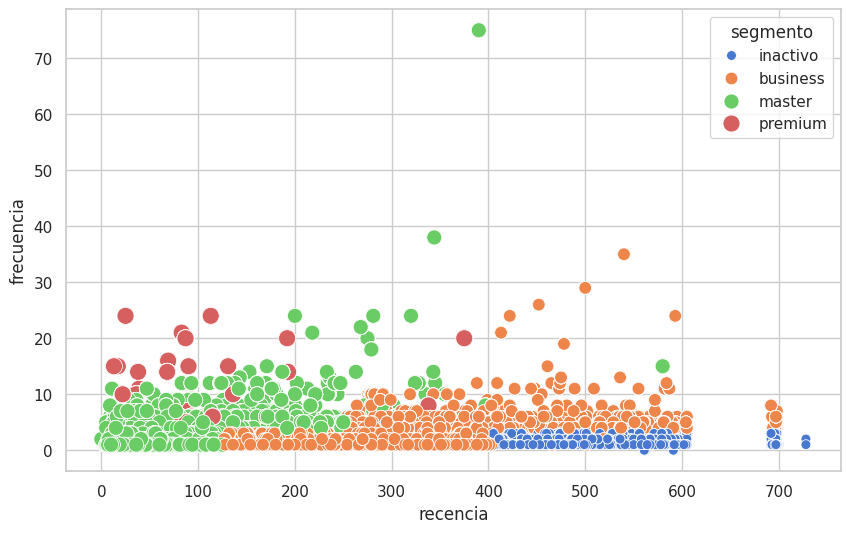

In [ ]:
# 2°) Ahora vamos a realizar nuestras graficas, pasamos lo que queremos analizar a la funcion ---->

plot_segmento("recencia", "frecuencia", df_final)

***Analisis visual Grafica*** (recencia, frecuencia)

Y aquí tenemos entonces nuestra primera gráfica. ¿Qué me muestra ella? Que aquí en mi recencia noten ustedes los puntitos que están en azul es la gente que pertenece al segmento inactivo, es decir, los que compraron hace más de 400 días, hace un año y tres meses.

Y no solamente eso, sino que compraron poquito, vean la frecuencia, compraron poquito, entonces estos puntitos azules que vemos aquí son los clientes inactivos. Después yo tengo mis clientes business, que son estos que están en naranja, que es la gente con la que yo puedo hacer negocios que no han comprado mucho.

Vean ustedes, la frecuencia, no es tanta, pero que están aquí en esta región. Es gente con la que yo pueda hacer negocios. Es gente que yo debo ver la manera de llegarles, tal vez cautivarlos a través de una promoción. Hacer algo especial con ellos. También tengo los clientes master, que son mis clientes que compran con una cierta frecuencia, o bastante frecuencia, pues con cierta frecuencia, no podemos decir bastante porque es hasta 20 o 15.

Bueno, tenemos estos por acá, pero noten ustedes que yo tengo aquí un outlier. Vean. ¿Esta persona, quién es? Que compra bastante, pero dejó de comprar hace ya casi 400 días. O sea hace más de un año. ¿Por qué dejó de comprar? Yo tengo que darle mucha atención a esta persona, tratar de ubicar a este cliente y ver qué podemos hacer, por qué él dejó de comprar.

Entonces este outlier aquí es un insight valioso para nuestro gerente, compraba bastante y dejó de comprar hace mucho tiempo. Bueno, eso por un lado, el análisis más detallado lo veremos en las conclusiones.

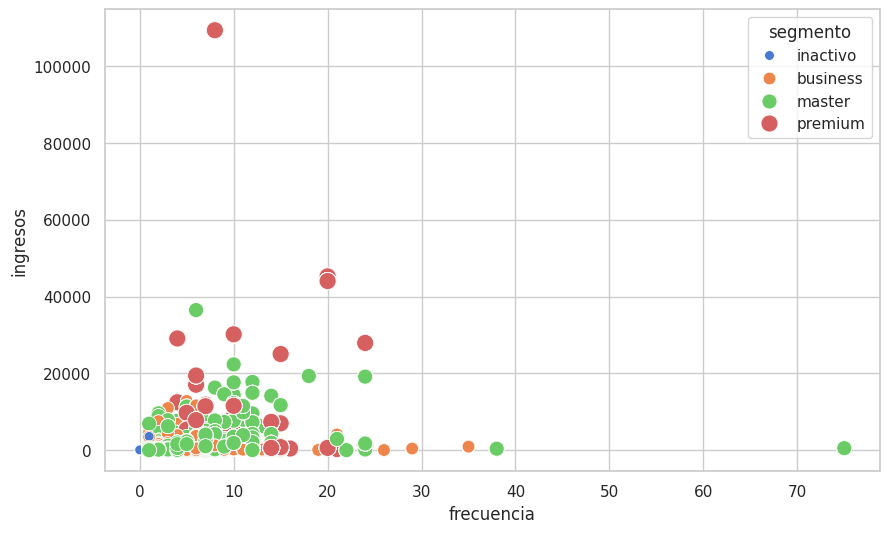

In [ ]:
# 3°) Vamos a hacer una nueva grafica --->

plot_segmento("frecuencia", "ingresos", df_final)

***Analisis visual Grafica*** (frecuencia, ingresos)

Por ejemplo, ese puntito azul se ve bien pequeñito, que pues no tuvo frecuencia de compras y tampoco gastó mucho. Entonces ellos están en el cluster 0. Son los inactivos.

Pero si yo comienzo a observar aquí realmente los premium se destacan que son estos puntos rojos que son un poco más grandes. Noten ustedes, por eso yo les puse el size aquí, para que el puntito de premium fuera más grande, más visible. Y yo tengo, por ejemplo, este cliente aquí, que no compra con mucha frecuencia, pero que cuando lo hace compra bien. O sea, más de 100000.

Entonces a este cliente yo le tengo que dar, por ejemplo, un trato muy especial, digamos este no es el tipo de personas que tal vez se sienta contento con un cupón. Tal vez él quiera un trato más personalizado, colocarle un vendedor específico que lo atienda y que de repente le ofrezca nuevos productos, cosas que sean interesantes.

Pero estos son los clientes, estos son los tipos de clientes que más hay que cuidar. Porque son los que generan más ingresos para la empresa, entonces pues es otro insight valioso

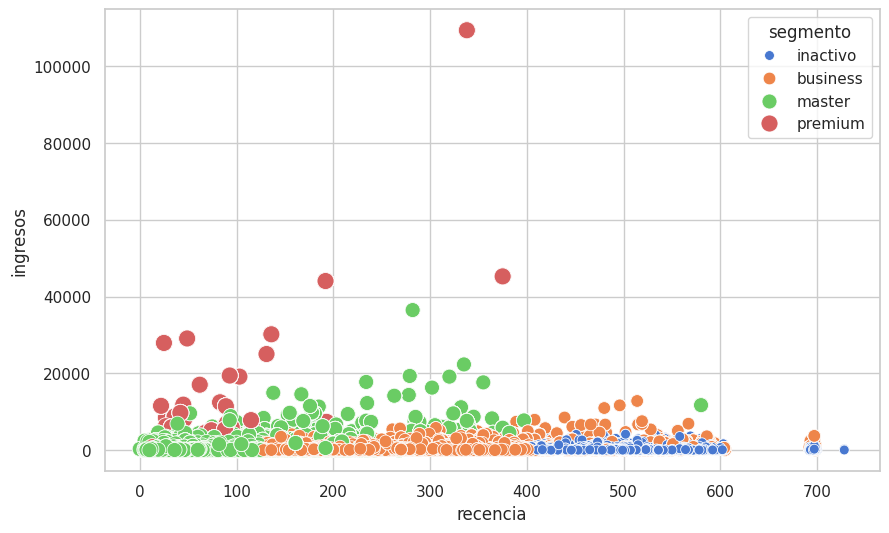

In [ ]:
# 4°) Hacemos otro PLOT ---->

plot_segmento("recencia", "ingresos", df_final)


***Analisis visual Grafica*** (recencia, ingresos)

En x voy a ver la recencia con respecto a los ingresos. Entonces sería ‘recencia’, ‘ingresos’ y mi DataFrame que es el df_final.

Entonces de esta manera, pues yo voy a ver las personas que han comprado de los últimos días y los ingresos. Entonces este también es un insight muy valioso, me permite a mí visualizar, por ejemplo, que yo tengo clientes Premium. Un cliente premium que dejó de comprar, vean ustedes, hace como un año. ¿Por qué? ¿Por qué este cliente de comprar hace un año?

Entonces esto también es muy valioso para mis negocios, porque quiere decir que esta persona que gastó tanto, está por aquí arriba, es uno de los que más ingresos ha dado. Entonces dejó de comprar hace más de un año, entonces hay que contactarlo. Esto de aquí también hay que contactarlos, hay que ver por qué hace, por ejemplo, por qué hace más de un año no compra.

¿Qué pasa? ¿No le hemos ofrecido? ¿No le hemos cuidado lo suficiente? A este aquí también. ¿Por qué no hemos estado pendientes de él? ¿Por qué ha dejado de comprar? Entonces estar pendiente y noten ustedes la recencia, los inactivos, aquí está el puntito azul, inactivo y lógicamente son los que menos ingresos van a generar a la empresa.

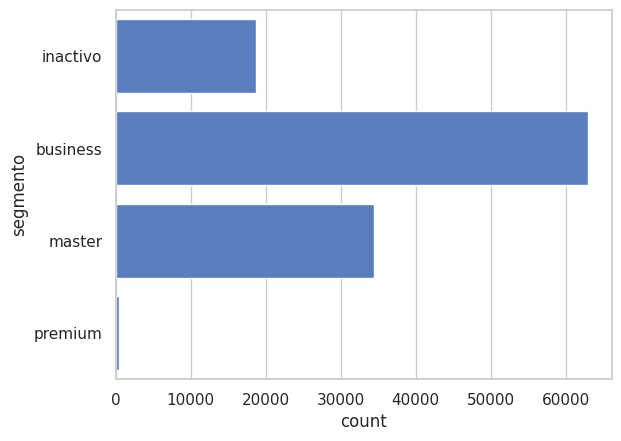

In [ ]:
# 5°) Vamos hacer un COUNTPLOT del segmento --->

sns.countplot(df_final["segmento"]);


***Analisis visual Grafica*** (countplot segmento)

Y vamos a tomar únicamente el segmento, que fue los datos que yo generé utilizando el value_counts. Entonces aquí vemos nosotros que, efectivamente, la mayoría de mis clientes están en el segmento business.

Entonces, estos clientes aquí son pues la mayoría. Tengo que estar pendiente de ellos, tenerlos contentos, tratar de hacer que estos clientes business se vuelvan master. De hecho tengo una buena cantidad de clientes aquí en el segmento master y noten ustedes que los premium son bien poquitos. Bueno, era de esperarse.

Inactivos. Bueno, tengo también casi 20000 clientes en el área de los inactivos. ¿Entonces qué podemos hacer para activar a este grupo de clientes? De modo que en este momento ya hemos brindado una serie de insights importantes para nuestro gerente o para el equipo de marketing y ellos ya pueden entonces generar estrategias para poder llegar a esos clientes, ver qué pueden hacer aquí para mantener a los premium, tal vez hacer que estos masters se vuelvan Premium.



---


***Para saber más: el coeficiente de Silhouette***

Además del método del codo y del método matemático, existen otras maneras de determinar el número ideal de clusters. Una de ellas es el método de la silhueta, o Silhouette.

Si así lo deseas, puedes leer el siguiente artículo de Medium que habla un poco sobre el método. Dado que el texto está en inglés, a continuación encontrarás la traducción del párrafo que habla sobre el asunto:

Coeficiente de Silhouette: Esta es una mejor métrica para decidir el número de clusters que serán formulados a partir de los datos. Este coeficiente se calcula para cada instancia y la fórmula es la siguiente:

Donde y es la distancia promedio intra-cluster: Distancia promedio con relación a las otras instancias en el mismo cluster.

Y x representa la distancia promedio más cercana del cluster, o sea, la distancia promedio con relación a las instancias del siguiente cluster más cercano.

El coeficiente varía entre -1 y 1. Un valor cercano a 1 implica que la instancia está cercana al cluster y hace parte del cluster correcto. Por otro lado, un valor cercano a -1 significa que el valor está atribuído al cluster incorrecto.

De esta manera, considerando el gráfico del coeficiente de Silhouette que se muestra a continuación, el número de cluster debería ser 5, es decir, donde se presenta el valor mayor.



---



***Ejercicio:***

***Desafío: método de Silhouette***

En la actividad “Para saber más”, vimos que existe otro método para identificar el número ideal de clusters. Para ello, vamos a probar el siguiente código, en el cual el puntaje de Silhouette es empleado:



In [ ]:
#from sklearn.metrics import silhouette_samples, silhouette_score

#for i in range(2, 11):
    #clusterer = KMeans(n_clusters=i)
    #preds = clusterer.fit_predict(df_recencia)
    #score = silhouette_score(df_recencia, preds)
    #print('Puntaje de Silhouette para ' + str(i) + ' clusters : ' + str(score))

# Tarda mucho ejecucion:

#Puntaje de Silhouette para 2 clusters : 0.5987816654977525
#Puntaje de Silhouette para 3 clusters : 0.5768640100406878
#Puntaje de Silhouette para 4 clusters : 0.5582579019643469
#Puntaje de Silhouette para 5 clusters : 0.5583889526832209
#Puntaje de Silhouette para 6 clusters : 0.5595534462604808
#Puntaje de Silhouette para 7 clusters : 0.5630350661806022
#Puntaje de Silhouette para 8 clusters : 0.5529403711290719
#Puntaje de Silhouette para 9 clusters : 0.5567954452125824
#Puntaje de Silhouette para 10 clusters : 0.5681801542806305

***RTA SILHOUTTE:***

Observa que esta vez 2 clusters devuelve el mejor valor. En este caso, el coeficiente de Silhouette es el que más se aproxima a 1. Matemáticamente, podemos entender este acercamiento de la siguiente forma: Para cada valor ‘p’, encuentra primero la distancia promedio entre todos los otros valores en el mismo cluster (esta es una medida de cohesión, la llamaremos A). En seguida, encuentra la distancia promedio entre todos los valores en el cluster más cercano (esta es una medida de separación de otro cluster más cercano, lo llamaremos B). El coeficiente de Silhouette para este valor ‘p’ se define como la diferencia entre B y A dividida entre el valor máximo de las 2 (max (A, B)). De esta forma, se trata de una medida de correlación entre los dos análisis.

# <font color=red> **PRESENTACION DE RESULTADOS**


---

### **CREANDO OTROS SEGMENTOS**

Desarrollamos un sistema de puntuación para establecer diversos segmentos de clientes, pero únicamente definimos cuatro segmentos de clientes.

Nosotros podríamos definir más segmentos de clientes, de hecho aquí yo les traigo un ejemplo, cómo nosotros también podríamos definir a nuestros clientes observando más factores y estableciendo más categorías. Entonces creamos 11 segmentos.

Entonces, por ejemplo, creamos un segmento llamado **Campeones**, que son los que compraron recientemente, compran con frecuencia y gastan mucho, entonces ellos tienen valores de recencia, frecuencia e ingresos muy altos.

**Los clientes fieles**: gastan mucho y responden a las promociones, entonces ellos tienen un valor un poco más flexible de recencia, frecuencia e ingresos, pero considera un rango menor de puntuación.

**Los potencialmente fieles**. Compraron recientemente, pero de una vez, o sea, en una sola compra, compraron y gastaron una gran cantidad. Entonces ellos compraron recientes, pero no son muy frecuentes y pues pudieron haber gastado bastante.

También **nuevos clientes**, compraron recientemente, pero no compran con frecuencia, o sea se está priorizando el valor de recencia. Noten ustedes que la frecuencia puede ser menor o igual a 1 y los ingresos también menor o igual a 1. Entonces son nuevos clientes.

**Promisores** compraron recientemente, pero no gastaron mucho. Entonces también compraron recientemente, pero el gasto fue poco. Entonces, nuevos clientes y promisores son categorías muy similares. Necesitan atención, recencia, frecuencia y valor monetario por encima del promedio.
Entonces a ellos hay que atenderlos mejor, tal vez brindarles una atención un poco más personalizada, buscarlos, entrar en contacto con ellos. Casi en riesgo. Recencia, frecuencia y valor monetario por debajo del promedio. Entonces, son personas o son clientes a los cuales no podemos descuidar, están casi en un riesgo de que los perdamos, entonces hay que estar pendiente de ellos.

**En riesgo**. Gastaron mucho, compraron muchas veces, pero hace mucho tiempo. Estos que están en riesgo son clientes críticos, nosotros debemos estar muy atentos porque ellos gastaron mucho con mucha frecuencia, pero hace mucho tiempo entonces a estos que están en riesgo, hay que buscarlos, no los podemos perder, como dice aquí no se pueden perder, compraron mucho y con frecuencia, pero hace mucho tiempo se parece a los que están en riesgo.

O sea en riesgo y no se pueden perder, fue porque tuvieron más frecuencia que los que estaban en riesgo y también gastaron mucho más de los que estaban en riesgo. Entonces esto no se pueden perder. Hibernando, compraron poco, con baja frecuencia y hace mucho tiempo, entonces son casi **inactivos**, pero están ahí.

También tienen un sistema de puntuación aquí bajito. Y los que están perdidos dice aquí recencia, frecuencia y valores monetarios bajos. Entonces, ellos, realmente, pues ya no está más motivados o animados con la empresa, entonces hay que también ver alguna estrategia que se pueda aplicar a este tipo de clientes.

***¿Entonces, qué estrategias podemos aplicar? ¿Cuáles estrategias podemos aplicar?:***

Veamos a ver 7 estrategias:

* 1 - Debemos enfocarnos en la satisfacción del cliente, que coloquemos todos nuestros esfuerzos en mantener a los clientes satisfechos, que siempre les ofrezcamos una experiencia positiva tras cada negociación, que ellos se sientan felices.

* 2 - Segunda estrategia que podemos implementar es volver las interacciones más personales, que muchas veces las personas, todos, digamos, yo me incluyo, tenemos dificultad asociando a una empresa con una conexión o con construir una relación más personal, más cercana con la empresa.
Entonces, para que mis clientes o para que estos clientes regresen y quieran comprar, debemos hacer que ellos se sientan más deseados y todo eso se logra volviendo la interacción más personal, por ejemplo a veces una nota que sea específica con el nombre de la persona y tal vez usar como es por e-commerce, tal vez digitalizar algo escrito a mano sería interesante.
La persona dice: “Oye, se tomó el tiempo y la molestia de, digamos recordar, por ejemplo, que era mi cumpleaños y me mandó un mensaje”. Bueno, interesante.

* 3 - Otra estrategia, construir una comunidad. Entonces, si nosotros tenemos un negocio tradicional, debemos considerar la posibilidad de realizar eventos para que los clientes puedan conocer otras personas con ideas semejantes en el área, o sea, en esa misma área de acción. Entonces se realiza un evento.
Si por ejemplo, estás en una empresa que trabaja con la parte de construcción civil, entonces la idea sería traer a varias personas que trabajen en el área, reunirlas y que ellos realicen pues conexiones, creen conexiones con estas personas que también están en el área.

* 4 - Una cuarta estrategia, ofrecer recompensas instantáneas sin compromiso, que la persona no se sienta comprometida. Lógicamente debemos certificarnos de obtener alguna información de contacto, pues de estas personas, pero también cuando enviemos esa recompensa que no se la enviemos como un spam o como un correo que sea irrelevante para ellos.
Siempre, digamos ser muy cuidadosos en este sentido y tratar de involucrar a estos clientes siempre, nuevamente, tenerlos involucrados.

* 5 - Otra estrategia, crear un programa de fidelidad. Digamos que nuestros clientes sientan que tienen algo por lo cual pueden trabajar a largo plazo, algo, por ejemplo, que van acumulando puntos.
Nosotros hemos observado que muchas empresas, sobre todo, supermercados, tienen este método de cliente fiel. Entonces siempre la persona digita un número y entonces suma puntos y al final le dan una recompensa a la persona, entonces todo esto hace que la persona quiera mantenerse activa comprando, realizando negocios, porque mientras más compra, más puntos acumula y más oportunidades tiene de ganar algún premio.
Y entonces esa persona se va a mantener fiel a ti y no va a buscar la competencia.

* 6 - Otra estrategia. Crear un programa VIP. Entonces esta sería una variante del programa de fidelidad y este es proyectado específicamente para los clientes de alto nivel, o sea, para los que más compran, con más frecuencia y de una manera más reciente, o sea que uno está ahí pendiente de estas personas como que vendrían siendo como el segmento de los clientes, campeones, ellos.
Ellos tendrían, digamos, la posibilidad de hacer grupo de este programa VIP y ellos deben sentirse muy bien. Esto sí, digamos es el grupo de clientes en los cuales debemos colocar bastante esfuerzo para mantenerlos.

* 7 - Y finalmente aumentar la presencia en redes sociales.
Las redes sociales van a permitir que tu empresa tenga acceso directo a los usuarios y van a mantenerlos actualizados sobre cualquier oferta o promoción, como cuando tú, por ejemplo, te metes a Instagram o a Twitter o a Facebook, lógicamente te llega propaganda, y esa propaganda viene con contenido dirigido a ti y te llama la atención.
Entonces la idea es poder cautivar a este tipo de clientes. De modo que estas son algunas de las estrategias que nosotros podemos implementar para nuestros segmentos de clientes.

**Definicion:**

***Puntuación y segmentación***

Después de realizar la clusterización y la segmentación de clientes, una serie de actividades pueden ser conducidas por el equipo de marketing con el objetivo de aumentar las ventas, conversión y retención de clientes, entre otros.

Sobre la última aula y con base en todo el curso, señala alternativas:

* La segmentación de clientes abre el camino a otros análisis de marketing.
Un buen ejemplo es el Análisis DOFA - esto es, Debilidades, Oportunidades, Fortalezas y Amenazas - de y para tu negocio.

* Segmentar a los clientes correctamente no solo mejora la conversión de compras, sino la retención de clientes. La segmentación de clientes permite ajustar el producto o el servicio que ofreces a tus clientes para atender mejor sus necesidades, aumentando su confianza en tu marca.

### **INFORME DE RESULTADOS**

Muy bien. En el video anterior discutimos varias estrategias que podíamos aplicar para los diversos segmentos de clientes que obtuvimos después de realizar todo nuestro análisis.
Pero ahora llegó el momento de mostrar nuestros resultados al equipo de marketing o inclusive a nuestro gerente, y muchas veces estos equipos o estas personas no conocen mucho, digamos, la parte de algoritmos o la parte de código, cómo se trabaja con estas herramientas informáticas.

[00:30] Pero entonces a ellos sí les interesa los insights, lo que se descubrió a través de todo este trabajo analítico. Entonces vamos a hablar un poco sobre la presentación de nuestros resultados.

**Aqui vamos primeramente a presentar nuestro informe**:

En nuestro informe, debemos decir que utilizamos:

* La técnica de segmentación a través de la clusterización mediante el modelo **RFM**.

* El modelo de marketing RFM es **recencia**:  que responde la pregunta ¿hace cuántos días fue la última compra de este cliente?

* **La frecuencia:** ¿cuántas compras ha realizado este cliente en tu empresa desde que se registró? Y los ingresos: ¿Cuánto dinero ha gastado este cliente en tu empresa? Entonces empleamos esta técnica de segmentación llamada RFM. De la misma manera vamos a hablar sobre el modelaje.

* Entonces para modelar, nosotros trabajamos, **el algoritmo KMeans**:
Definimos a través del algoritmo KMeans que era necesario 4 clusters para segmentar a nuestros clientes por cada conjunto RFM. Entonces, 4 clusters para recencia, cuatro clusters para frecuencia y cuatro clusters para ingresos. Todo estose definió basándonos en la **regla del codo** y en la **regla matemática** que verdaderamente nos permitió especificar que el número ideal de clusters era 4.

Creamos entonces un sistema de puntuación o de score en el cual nosotros sumábamos, entonces el número asignado a cada cliente de acuerdo con el cluster al que pertenecía. Y con este sistema de puntuación pudimos definir cuatro segmentos de clientes:

**Segmento inactivo, el segmento business, el segmento master y el segmento premium:**

Y pudimos entonces realizar una visualización global de nuestro segmento de clientes. Entonces, pudimos notar que, por ejemplo:

* **El segmento business** era el que más clientes tenía. Teníamos 54.03% de clientes en el **segmento business**. En el **segmento máster** 29.72%, y en el Premium, como era de esperarse, menos del 1% de clientes.

Entonces ya sabemos que nosotros a este segmento premium podemos darle verdaderamente una atención especializada, porque no solamente son pocos, sino que también son los que más ingresos generan para la empresa. Inactivos, por ejemplo, hay que tenerla muy en cuenta y tenemos también el casi 20000 clientes inactivos. ¿Entonces qué podemos hacer?

Vamos a ver algunas acciones que nosotros podemos adoptar de acuerdo con estos resultados en nuestros segmentos. Lo primero sería recuperar estos clientes inactivos. Recuerden que son alrededor de 20000 clientes, entonces promociones y cupones especiales para ellos.

Ofrecer descuentos especiales para el envío de los productos a los clientes que pertenecen al segmento master entonces, hacerles un descuento especial en el
shipping o en la entrega, y también descuentos especiales para los premium y lógicamente ofrecerles una atención especializada.

Esa sería como la visualización global. Y finalmente vamos a hablar de algunos casos puntuales. El primero de ellos es el que nos muestra a nosotros la frecuencia de compra con respecto a la recencia. Entonces nosotros aquí tenemos casos puntuales.

Tenemos por ejemplo, en un cliente promisorio que compró muy recientemente, hace parte del segmento premium, compró recientemente y con una frecuencia considerable. Entonces a esta persona la queremos tener activa, queremos hacerle recomendaciones de productos.

Tenemos también, por ejemplo, aquí un cliente business, que compró hace mucho tiempo, pero compró con bastante frecuencia, entonces a él ese es el tipo de cliente que en inglés se conoce como sleepy o que sería resbaladizo. A esta persona hay que hacerle promociones, hay que tratar de volverlo reciente, hay que tratar de hacerlo master.

Tenemos por aquí un outlier, no lo tenemos indicado, pero este outlier master aquí nos llama la atención. Porque compró bastante con bastante frecuencia y hace bastante tiempo. Esté aquí tampoco lo podemos descuidar. Bueno, tener eso en cuenta. De la misma manera, cuando graficamos los ingresos con respecto a la frecuencia entonces, nosotros observamos aquí los clientes que se conocen como whales o ballenas, entonces a ellos les damos una atención especializada.

Entonces vean, ustedes no compró con mucha frecuencia, la frecuencia está baja, pero los ingresos que dieron son muchos y él hace parte del segmento premium. Entonces a esta persona o cliente hay que darle una atención
especializada. Y también tenemos los clientes leales o los que ya están fidelizados, entonces ellos compran con una cierta frecuencia y compran bastante.

Entonces ellos se les ofrecen descuentos especiales. A estas personas hay que tenerlas bien activas comprando, dándoles descuento. De la misma manera tenemos entonces por ejemplo, esta gráfica de ingresos con respecto a la recencia, entonces noten ustedes, tengo la recencia y tengo aquí una persona que compró un cliente que compró hace más de un año.

Vean ustedes, o casi un año por ahí, y compró muchísimo y era el segmento premium. ¿Qué pasó con este señor? Entonces, él mezcla dos factores, mezcla la característica de ser whale o una ballena y también ser un sleeping. Entonces sería un sleeping whale.

Entonces, esta ballena resbaladiza este no lo podemos perder. ¿Qué pasó? Compró mucho, pero dejó de comprar hace mucho tiempo. ¿Qué pasó con ese cliente? Hay que entonces ver qué podemos realizar. De modo que de esta manera, el equipo de marketing o la gerencia de la empresa ya va a tener conocimientos o insights bastante valiosos para tomar decisiones estratégicas en beneficio de nuestra e-commerce.